## Import libraries and setup

In [1]:
import os
from pathlib import Path

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')


import warnings
warnings.filterwarnings('ignore')

In [2]:
%pwd

'f:\\Samith\\Github\\grid-forecast\\research'

In [3]:
os.chdir("../")

In [4]:
df = pd.read_parquet('artifacts/preprocessed/power_consumption_preprocessed.parquet')

In [5]:
TARGET = 'load_Actual Load'

In [6]:
df_sarima = df[TARGET].resample('h').mean()
df_sarima = df_sarima.interpolate(method="time", limit_direction="both")
print(df_sarima.shape)

(64763,)


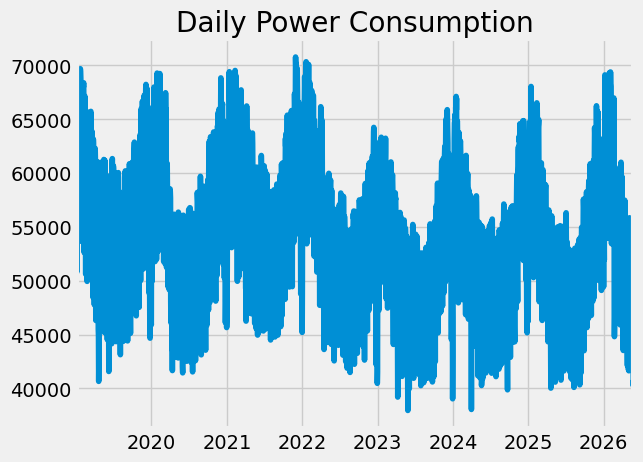

In [7]:
# Daily Power Consumption
df[TARGET].resample('D').mean().plot(title="Daily Power Consumption")

plt.show()

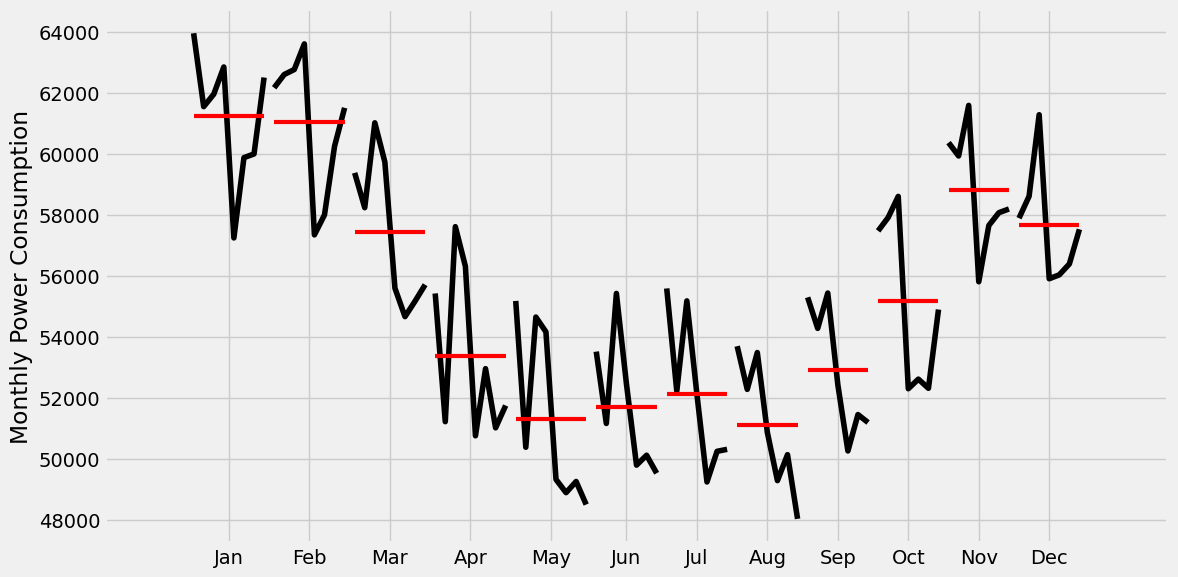

In [8]:
# Plotting the monthly seasonality

fig, ax = plt.subplots(figsize=(12, 6)) 
month_plot(df[TARGET].resample('ME').mean(),
           ylabel='Monthly Power Consumption', ax=ax)

plt.tight_layout()

plt.show()

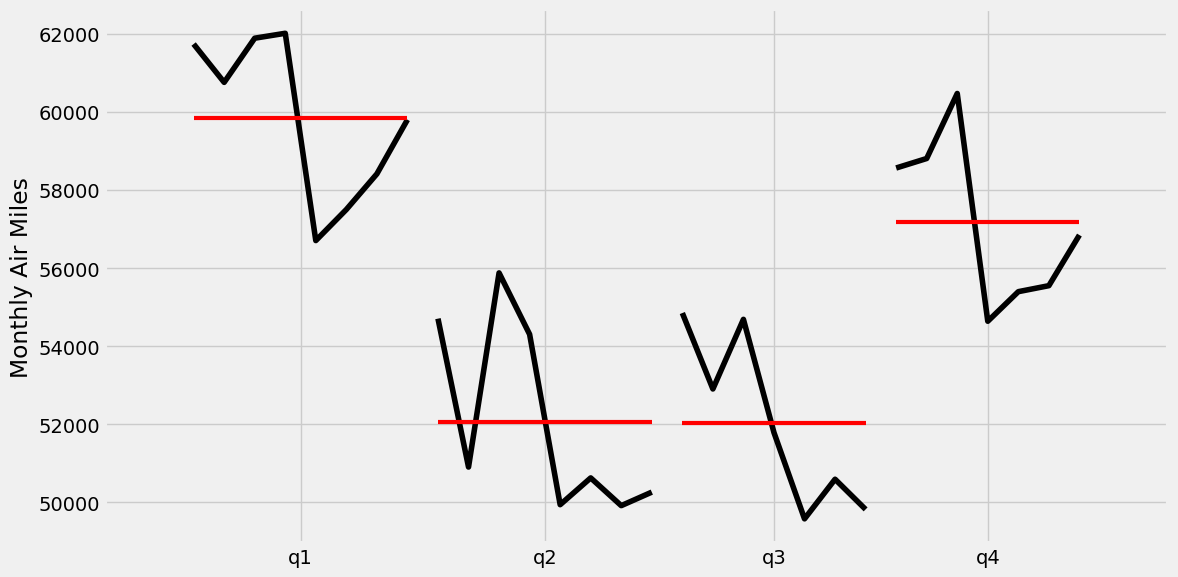

In [9]:
fig, ax = plt.subplots(figsize=(12, 6)) 
quarter_plot(df[TARGET].resample('QE').mean(),
           ylabel='Monthly Air Miles', ax=ax)
plt.tight_layout()
plt.show()

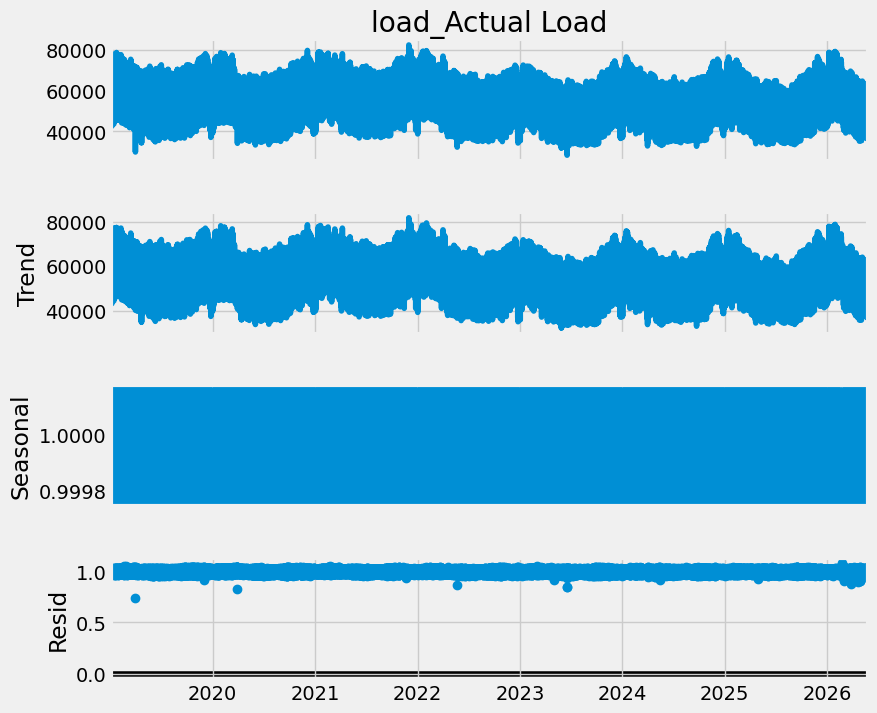

In [10]:
# Seasonal Decomposition PLots

decomposition = seasonal_decompose(df[TARGET], model='mul', period=12)
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

ADF Statistic: -18.4424
p-value: 0.0000


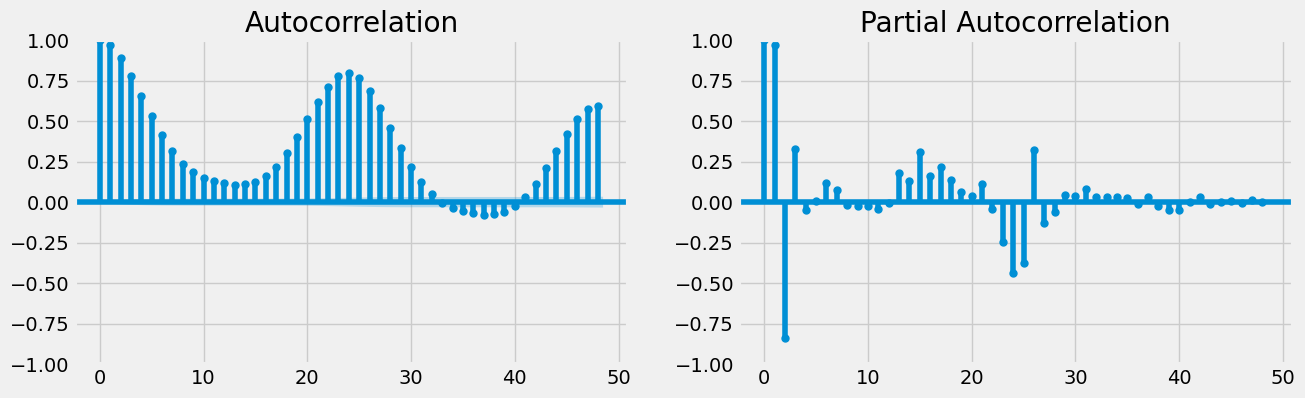

In [11]:
result = adfuller(df_sarima.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# p-value < 0.05 means stationary — no differencing needed (d=0)
# p-value > 0.05 means non-stationary — need d=1

# Plot ACF and PACF to find p and q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_sarima.dropna(), lags=48, ax=axes[0])
plot_pacf(df_sarima.dropna(), lags=48, ax=axes[1])
plt.show()

In [12]:


# Train/test split 
train_sarima = df_sarima[(df_sarima.index > '2025-05-01') & (df_sarima.index < '2026-05-01')]
test_sarima  = df_sarima[df_sarima.index >= '2026-05-01']


order         = (2, 1, 1) 
seasonal_order = (1, 1, 1, 24)


predictions = []
actuals     = []

# Forecast one day at a time
forecast_horizon = 24  # 24 intervals = 1 day

# Refit every week
refit_frequency = 168  # 168 intervals = 1 week

history = train_sarima.copy()
fitted_model = None

print(f"Test size: {len(test_sarima)} hours")

for i in range(0, len(test_sarima), forecast_horizon):

    actual_window = test_sarima.iloc[i:i + forecast_horizon]

    if len(actual_window) == 0:
        break

    # Fit initially, then refit every week
    if fitted_model is None or i % refit_frequency == 0:
        print(f"Fitting model at step {i}/{len(test_sarima)}...")

        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

    # Forecast next 96 intervals
    forecast = fitted_model.forecast(steps=len(actual_window))

    predictions.extend(forecast.values)
    actuals.extend(actual_window.values)

    # Update model state with actual observations before next forecast
    fitted_model = fitted_model.append(actual_window, refit=False)

    # Keep history updated for weekly refits
    history = pd.concat([history, actual_window])

# Evaluate
predictions = np.array(predictions)
actuals = np.array(actuals)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print("\nSARIMA Results:")
print(f"  RMSE: {rmse:.0f} MW")
print(f"  MAE:  {mae:.0f} MW")
print(f"  MAPE: {mape:.2f}%")

Test size: 600 hours
Fitting model at step 0/600...
Fitting model at step 168/600...
Fitting model at step 336/600...
Fitting model at step 504/600...

SARIMA Results:
  RMSE: 5162 MW
  MAE:  3744 MW
  MAPE: 7.88%


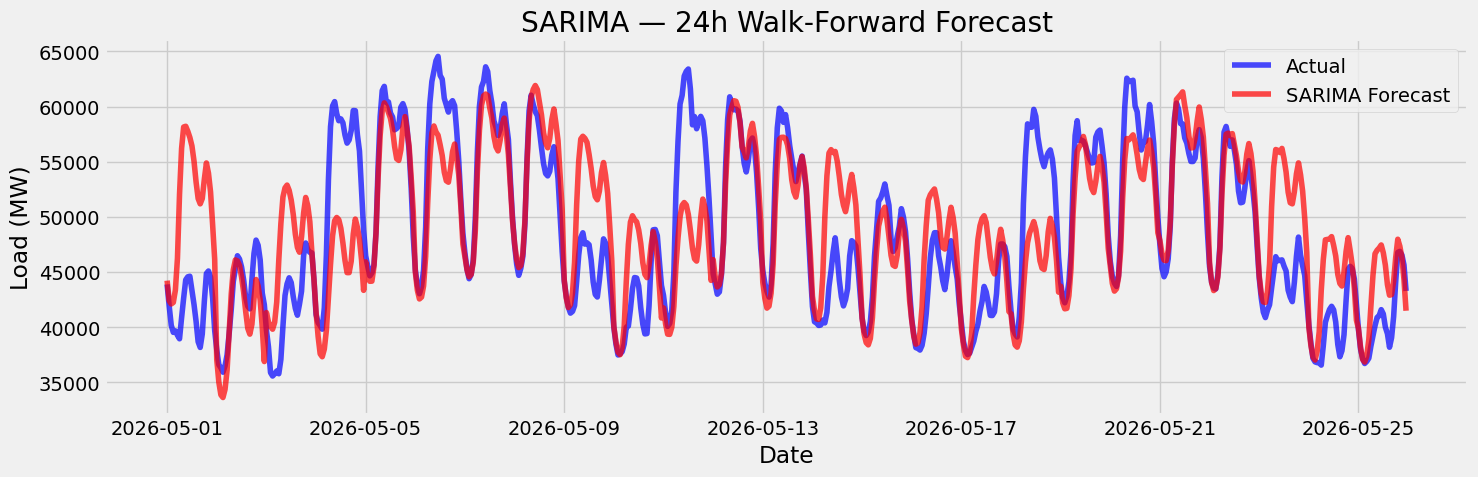

In [13]:

plt.figure(figsize=(15, 5))
plt.plot(test_sarima.index[:len(actuals)], actuals, 
         label='Actual', color='blue', alpha=0.7)
plt.plot(test_sarima.index[:len(predictions)], predictions, 
         label='SARIMA Forecast', color='red', alpha=0.7)
plt.title('SARIMA — 24h Walk-Forward Forecast')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()
